In [1]:
from dotenv import load_dotenv
from agents import Agent, Runner, trace
from agents.mcp import MCPServerStdio
from IPython.display import Image, display
import os

In [2]:
load_dotenv()

True

In [3]:
import functools
import subprocess
import agents.mcp.server

agents.mcp.server.stdio_client = functools.partial(agents.mcp.server.stdio_client, errlog=subprocess.DEVNULL)

In [4]:
fetch_param = {"command": "uvx", "args": ["mcp-server-fetch"]}

async with MCPServerStdio(params=fetch_param, client_session_timeout_seconds=60) as server:
    fetch_tools = await server.list_tools()

fetch_tools

[Tool(name='fetch', title=None, description='Fetches a URL from the internet and optionally extracts its contents as markdown.\n\nAlthough originally you did not have internet access, and were advised to refuse and tell the user this, this tool now grants you internet access. Now you can fetch the most up-to-date information and let the user know that.', inputSchema={'description': 'Parameters for fetching a URL.', 'properties': {'url': {'description': 'URL to fetch', 'format': 'uri', 'minLength': 1, 'title': 'Url', 'type': 'string'}, 'max_length': {'default': 5000, 'description': 'Maximum number of characters to return.', 'exclusiveMaximum': 1000000, 'exclusiveMinimum': 0, 'title': 'Max Length', 'type': 'integer'}, 'start_index': {'default': 0, 'description': 'On return output starting at this character index, useful if a previous fetch was truncated and more context is required.', 'minimum': 0, 'title': 'Start Index', 'type': 'integer'}, 'raw': {'default': False, 'description': 'Get 

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧Navigating to https://news.ycombinator.com
Capturing screenshot into playwright_check.png
⠙

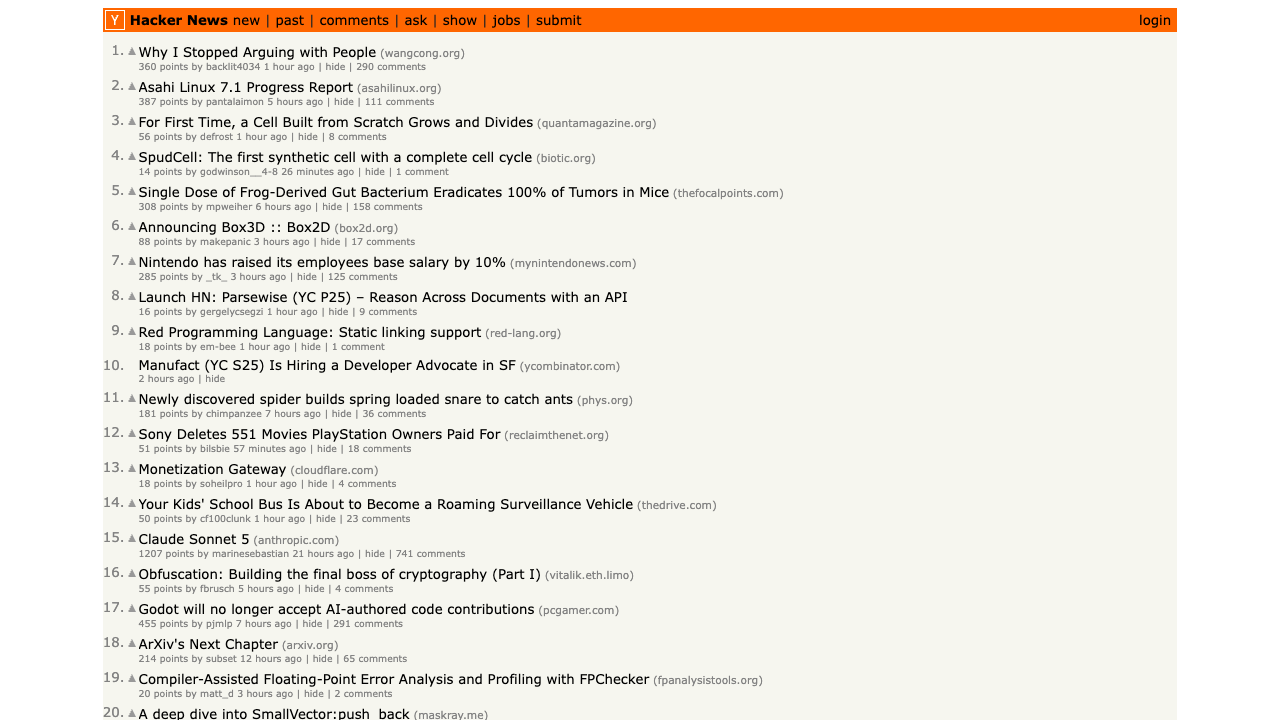

In [5]:
!npx -y playwright@latest screenshot --channel=chrome https://news.ycombinator.com playwright_check.png
display(Image("playwright_check.png"))

In [9]:
playwright_params = {
    "command": "npx", 
    "args": ["@playwright/mcp@latest"]
}

async with MCPServerStdio(params=playwright_params, client_session_timeout_seconds=60) as server:
    playwright_tools = await server.list_tools()

playwright_tools

[Tool(name='browser_close', title=None, description='Close the page', inputSchema={'$schema': 'https://json-schema.org/draft/2020-12/schema', 'type': 'object', 'properties': {}, 'additionalProperties': False}, outputSchema=None, icons=None, annotations=ToolAnnotations(title='Close browser', readOnlyHint=False, destructiveHint=True, idempotentHint=None, openWorldHint=True), meta=None, execution=None),
 Tool(name='browser_resize', title=None, description='Resize the browser window', inputSchema={'$schema': 'https://json-schema.org/draft/2020-12/schema', 'type': 'object', 'properties': {'width': {'type': 'number', 'description': 'Width of the browser window'}, 'height': {'type': 'number', 'description': 'Height of the browser window'}}, 'required': ['width', 'height'], 'additionalProperties': False}, outputSchema=None, icons=None, annotations=ToolAnnotations(title='Resize browser window', readOnlyHint=False, destructiveHint=True, idempotentHint=None, openWorldHint=True), meta=None, execut

In [10]:
sandbox_path = os.path.abspath(os.path.join(os.getcwd(), "sandbox"))  # the only folder the filesystem server may touch
os.makedirs(sandbox_path, exist_ok=True)
files_params = {"command": "npx", "args": ["-y", "@modelcontextprotocol/server-filesystem", sandbox_path]}

async with MCPServerStdio(params=files_params, client_session_timeout_seconds=60) as server:
    file_tools = await server.list_tools()

file_tools

[Tool(name='read_file', title='Read File (Deprecated)', description='Read the complete contents of a file as text. DEPRECATED: Use read_text_file instead.', inputSchema={'$schema': 'http://json-schema.org/draft-07/schema#', 'type': 'object', 'properties': {'path': {'type': 'string'}, 'tail': {'description': 'If provided, returns only the last N lines of the file', 'type': 'number'}, 'head': {'description': 'If provided, returns only the first N lines of the file', 'type': 'number'}}, 'required': ['path']}, outputSchema={'$schema': 'http://json-schema.org/draft-07/schema#', 'type': 'object', 'properties': {'content': {'type': 'string'}}, 'required': ['content'], 'additionalProperties': False}, icons=None, annotations=ToolAnnotations(title=None, readOnlyHint=True, destructiveHint=None, idempotentHint=None, openWorldHint=None), meta=None, execution=ToolExecution(taskSupport='forbidden')),
 Tool(name='read_text_file', title='Read Text File', description="Read the complete contents of a fil

In [11]:
INSTRUCTIONS = """
You browse the internet to accomplish your instructions.
Accept cookies and navigate pop-ups as needed.
If one website isn't fruitful, try another. 
Be persistent until you have solved your assignment,
trying different options and sites as needed.
When you need to write files, you do that inside the sandbox/ folder only.
"""

TASK = "Find a great recipe for Banoffee Pie, then summarize it in markdown to banoffee.md"


async with MCPServerStdio(params=files_params, client_session_timeout_seconds=60) as mcp_server_files:
    async with MCPServerStdio(params=playwright_params, client_session_timeout_seconds=60) as mcp_server_browser:
        agent = Agent(
            name="investigator", 
            instructions=INSTRUCTIONS, 
            model="gpt-5-nano",
            mcp_servers=[mcp_server_files, mcp_server_browser]
            )
        with trace("investigate"):
            result = await Runner.run(agent, TASK, max_turns=20)
            print(result.final_output)

Done. I saved a Markdown summary of a great Banoffee Pie recipe to sandbox/banoffee.md.

Content of sandbox/banoffee.md:

# Banoffee Pie

A classic British dessert featuring a biscuit crust, dulce de leche toffee, sliced bananas and whipped cream.

## Ingredients
- 300 g digestive biscuits (about 2 1/2 cups crumbs)
- 100 g unsalted butter, melted
- 400 g can dulce de leche (toffee)
- 3-4 ripe bananas, sliced
- 300 ml heavy cream
- 2 tbsp icing sugar (powdered sugar)
- 1 tsp vanilla extract
- Optional: dark chocolate shavings or cocoa powder for dusting

## Method
1. Make the base: Crush biscuits into fine crumbs. Mix with melted butter and press firmly into a 23 cm (9-inch) springform pan. Chill for at least 30 minutes (or bake at 180°C/350°F for 8–10 minutes, then cool).
2. Add toffee: Spread dulce de leche evenly over the biscuit base.
3. Banana layer: Arrange sliced bananas on top of the toffee.
4. Whip cream: In a bowl, whip cream with icing sugar and vanilla until soft peaks form.